# Import necessary libaries 

In [1]:
import pandas as pd
import numpy as np
# import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import mean_squared_error
# from tensorflow import keras
# from tensorflow.keras import layers, callbacks

RANDOM_SEED = 24

In [ ]:
new_df = pd.read_csv('02-14-2018.csv')
df = pd.read_csv('02-14-2018.csv')
print(new_df.head())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209              744   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                 0          0.0    

In [3]:
print(new_df.shape)

(1048575, 80)


In [4]:
new_df.drop(['Timestamp'], axis=1, inplace=True)

# cols_with_missing = [col for col in X.columns if X[col].isnull().any()]
new_df.replace([np.inf, -np.inf], np.nan, inplace=True)
new_df.dropna(inplace=True)

y = new_df.pop('Label')

In [5]:
new_df.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0,0,112641719,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761
1,0,0,112641466,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652
2,0,0,112638623,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098
3,22,6,6453966,15,10,1239,2273,744,0,82.600000,...,6,32,0.0,0.0,0,0,0.0,0.000000,0,0
4,22,6,8804066,14,11,1143,2209,744,0,81.642857,...,6,32,0.0,0.0,0,0,0.0,0.000000,0,0


It is assumed that the flow is either "Benign" or "Malicious". Hence, using ordinal encoding, "Benign" is encoded as 0, "FTP-Bruteforce" and "SSH-Bruteforce" are malicious, therefore encoded as 1.

In [6]:
y.replace(to_replace='Benign', value=0, inplace=True)
y.replace(to_replace='FTP-BruteForce', value=1, inplace=True)
y.replace(to_replace='SSH-Bruteforce', value=1, inplace=True)
y = y.astype(int)

/var/folders/4m/g_6893ld36vbb7dxvkc930h00000gp/T/ipykernel_5305/3173282236.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace(to_replace='SSH-Bruteforce', value=1, inplace=True)


A rescaling of the data is performed so that it does not confuse the model.

In [7]:
cols = new_df.columns[2:]
minMaxScaler = MinMaxScaler().fit(new_df[cols])
new_df[cols] = minMaxScaler.transform(new_df[cols])

In [8]:
# Split dataset into training, testing and validation
X_train, X_test, y_train, y_test = train_test_split(new_df, y, test_size=0.2, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_SEED)

In [9]:
X_train.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,...,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000,668640.000000
mean,4704.102100,8.112525,0.999876,0.001021,0.000787,0.000053,0.000338,0.002722,0.005750,0.003470,...,0.002721,0.485455,0.000475,0.000377,0.000808,0.000369,0.000009,0.000003,0.000005,0.000169
std,14192.005343,4.464319,0.001412,0.008759,0.011410,0.001944,0.011314,0.004547,0.013234,0.004810,...,0.005428,0.230827,0.005482,0.004024,0.006924,0.005271,0.001579,0.001540,0.001513,0.001529
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,6.000000,0.999869,0.000000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,6.000000,0.999869,0.000196,0.000109,0.000004,0.000004,0.000543,0.000000,0.002288,...,0.000000,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,443.000000,6.000000,0.999870,0.001369,0.000652,0.000053,0.000059,0.003119,0.000000,0.004992,...,0.003880,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,65533.000000,17.000000,1.000000,0.965976,1.000000,1.000000,1.000000,1.000000,0.832192,1.000000,...,1.000000,0.916667,1.000000,1.000000,1.000000,1.000000,0.983224,0.977323,0.968003,1.000000


In [11]:
y_train.value_counts()
y_val.value_counts()

Label
0    106297
1     60863
Name: count, dtype: int64

In [12]:
# prompt: using x train start training a random forest for classification

from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=RANDOM_SEED)
rf_classifier.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = rf_classifier.predict(X_val)

# Evaluate the model (example using accuracy)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy}")


Validation Accuracy: 1.0


### Building the model!

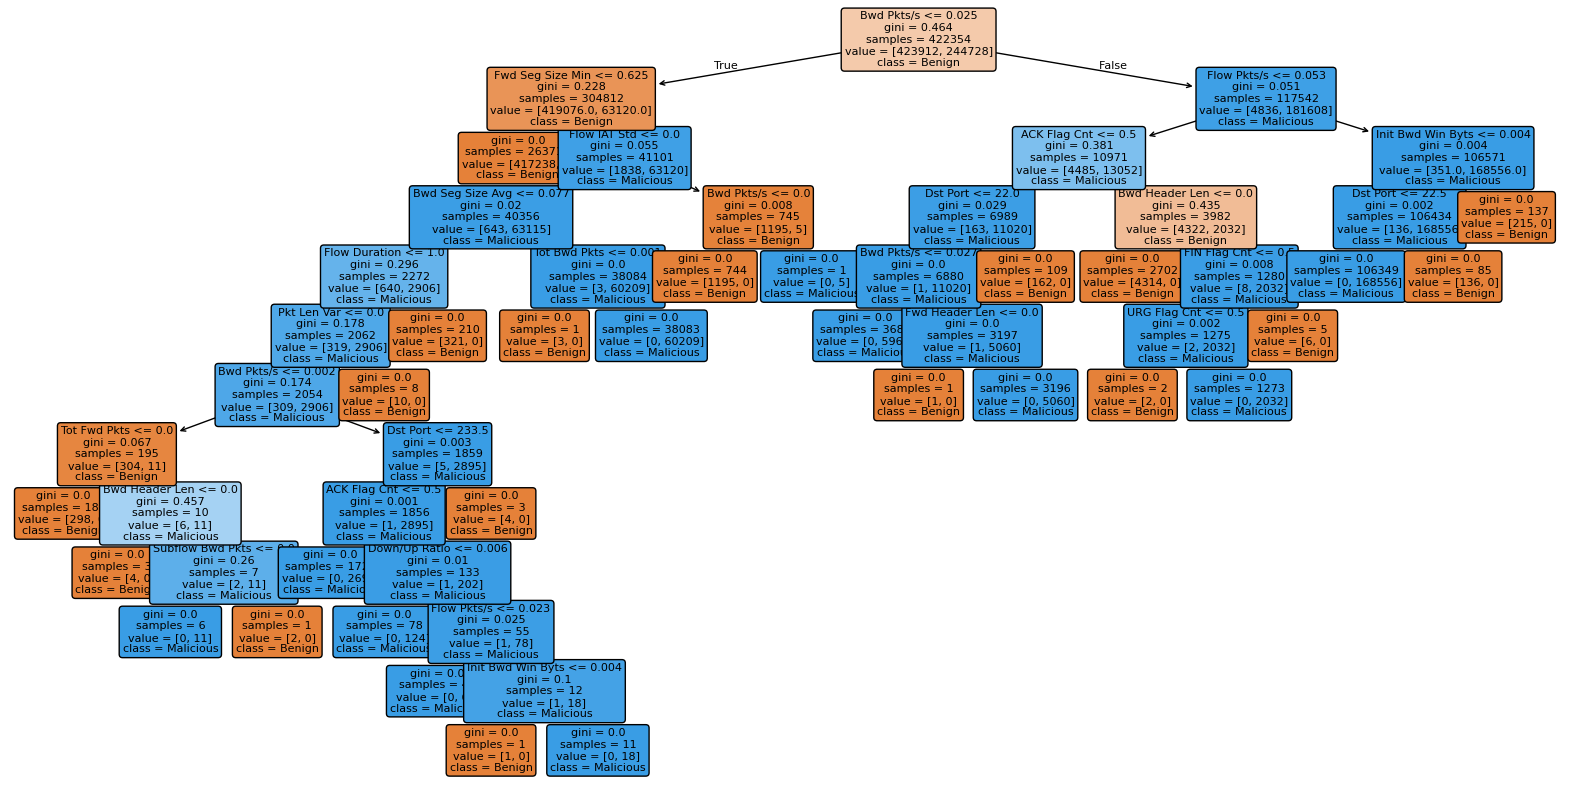

In [15]:
# prompt: visualise the model

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Assuming you have already trained the rf_classifier

# Visualize a single decision tree from the random forest
plt.figure(figsize=(20,10))
plot_tree(rf_classifier.estimators_[0],
          feature_names=X_train.columns,
          class_names=['Benign', 'Malicious'], # Assuming your class names
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

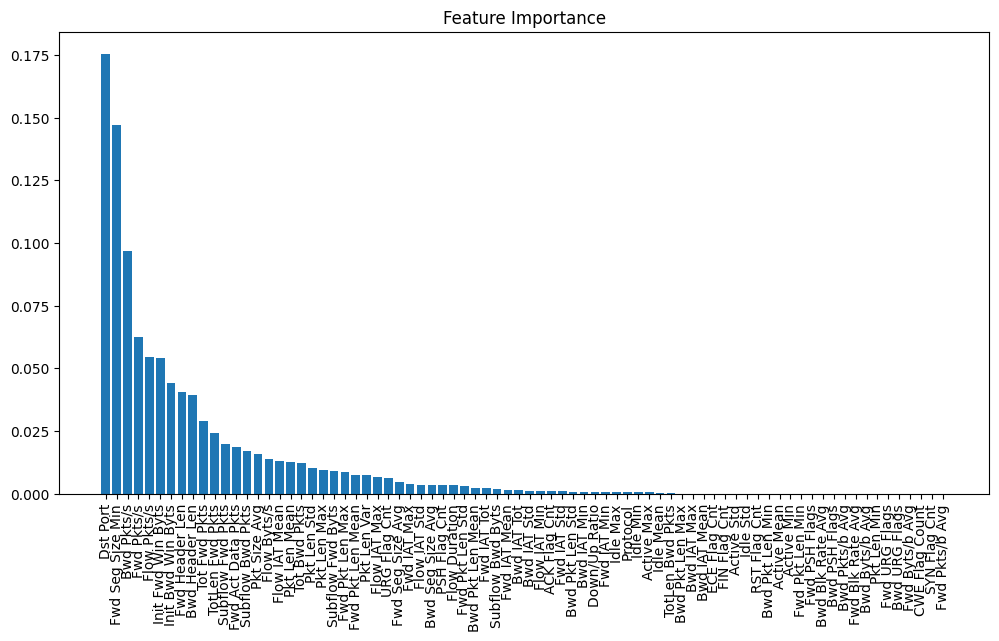

In [16]:

# Feature Importance Plot
feature_importances = rf_classifier.feature_importances_
feature_names = X_train.columns

# Sort feature importances in descending order
indices = np.argsort(feature_importances)[::-1]

# Rearrange feature names so they match the sorted feature importances
names = [feature_names[i] for i in indices]

# Create plot
plt.figure(figsize=(12,6))
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]), feature_importances[indices])
plt.xticks(range(X_train.shape[1]), names, rotation=90)
plt.show()


In [7]:
selected_features = [
    # Traffic Volume and Rate
    'Total Fwd Packets', 'Total Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s',
    
    # Packet Size and Behavior
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Fwd Packet Length Std', 'Bwd Packet Length Std',
    
    # Flow Duration and Timing
    'Flow Duration', 'Active Mean', 'Idle Mean',
    
    # Source/Destination Patterns
    'Src IP', 'Dst IP', 'Dst Port',
    
    # Protocol and Flag Anomalies
    'Protocol', 'SYN Flag Count', 'Fwd PSH Flags', 'Bwd PSH Flags',
    
    # Behavioral Features
    'Fwd Act Data Pkts', 'Min Packet Length',
    
    # Label (Target Variable)
    'Label'
]

# Check if columns exist in the dataset
missing_cols = [col for col in selected_features if col not in df.columns]
if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")
else:
    df_ddos = df[selected_features].copy()